# 01 — Data Collection
**NBA Player Performance & Trade Value Predictor**  
DATA 300 · Spring 2026 · Anh Vu & Drew Norton

---

### Goals of this notebook
1. Scrape **per-game stats** for all NBA players, seasons 2015–2024
2. Scrape **advanced stats** (PER, BPM, VORP, TS%, etc.)
3. Scrape **salary data** by player and season
4. Clean and merge everything into one unified `players_combined.csv`
5. Handle edge cases: traded players, missing values, duplicate rows

### Output
`data/raw/` — one CSV per stat type per season  
`data/processed/players_combined.csv` — final merged dataset ready for notebooks 02–05


---
## 0. Imports & Setup

In [59]:
# Install if needed (run once)
# !pip install requests beautifulsoup4 pandas numpy tqdm

import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import time
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Create directory structure
os.makedirs('data/raw/per_game',  exist_ok=True)
os.makedirs('data/raw/advanced',  exist_ok=True)
os.makedirs('data/raw/salaries',  exist_ok=True)
os.makedirs('data/processed',     exist_ok=True)

# Basketball-Reference blocks fast scrapers — always wait between requests
SLEEP_SECONDS = 4   # increase to 5-6 if you get 429 errors
SEASONS       = list(range(2016, 2025))  # 2016 = 2015-16 season, up to 2023-24
HEADERS       = {'User-Agent': 'Mozilla/5.0 (research project, Dickinson College DATA 300)'}

print(f'Seasons to collect: {SEASONS[0]} – {SEASONS[-1]}')
print(f'Total seasons: {len(SEASONS)}')
print('Setup complete.')

Seasons to collect: 2016 – 2024
Total seasons: 9
Setup complete.


---
## 1. Scraping Helper Functions

Basketball-Reference uses a consistent URL pattern:  
`https://www.basketball-reference.com/leagues/NBA_{year}_{table}.html`

Where `{table}` is one of: `per_game`, `advanced`, `totals`

In [62]:
def scrape_bref_table(year, table_type):
    """
    Scrapes a single season table from Basketball-Reference.
    
    Args:
        year (int): Season end year (e.g. 2024 = 2023-24 season)
        table_type (str): 'per_game' or 'advanced'
    
    Returns:
        pd.DataFrame or None if request fails
    """
    url = f'https://www.basketball-reference.com/leagues/NBA_{year}_{table_type}.html'
    
    try:
        response = requests.get(url, headers=HEADERS, timeout=15)
        
        if response.status_code == 429:
            print(f'  Rate limited on {year} {table_type} — waiting 30s...')
            time.sleep(30)
            response = requests.get(url, headers=HEADERS, timeout=15)
        
        if response.status_code != 200:
            print(f'  ERROR: status {response.status_code} for {year} {table_type}')
            return None
        
        soup = BeautifulSoup(response.content, 'html.parser')
        table_id = 'advanced' if table_type == 'advanced' else f'{table_type}_stats'
        table = soup.find('table', {'id': table_id})
        
        if table is None:
            print(f'  WARNING: table not found for {year} {table_type}')
            return None
        
        df = pd.read_html(str(table))[0]
        df['season'] = year
        return df
    
    except Exception as e:
        print(f'  EXCEPTION scraping {year} {table_type}: {e}')
        return None


def clean_bref_df(df):
    """
    Applies standard cleaning to any Basketball-Reference table:
    - Remove header rows that repeat mid-table (BRef quirk)
    - Remove players with 'TOT' team (traded player totals — keep individual stints separately)
    - Convert numeric columns
    - Remove players with fewer than 20 games
    """
    # BRef repeats column headers as rows every 20 rows — drop them
    df = df[df['Player'] != 'Player'].copy()
    
    # 'TOT' rows are season totals for traded players — we keep individual team stints
    # BUT for players who only appear as TOT (no trade mid-season), we keep TOT
    # Strategy: for each player-season, if TOT exists AND individual stints exist, drop TOT
    if 'Tm' in df.columns:
        has_tot = df[df['Tm'] == 'TOT'][['Player', 'season']].drop_duplicates()
        has_tot['has_tot'] = True
        df = df.merge(has_tot, on=['Player', 'season'], how='left')
        
        non_tot = df[df['Tm'] != 'TOT'][['Player', 'season']].drop_duplicates()
        non_tot['has_non_tot'] = True
        df = df.merge(non_tot, on=['Player', 'season'], how='left')
        
        # Drop TOT rows only when individual stint rows also exist
        df = df[~((df['Tm'] == 'TOT') & (df['has_non_tot'] == True))]
        df = df.drop(columns=['has_tot', 'has_non_tot'], errors='ignore')
    
    # Convert all numeric columns
    for col in df.columns:
        if col not in ['Player', 'Tm', 'Pos', 'season']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Filter minimum games
    if 'G' in df.columns:
        df = df[df['G'] >= 20]
    
    # Clean player names (remove asterisks BRef adds for Hall of Famers)
    df['Player'] = df['Player'].str.replace('*', '', regex=False).str.strip()
    
    return df.reset_index(drop=True)


print('Helper functions defined.')

Helper functions defined.


---
## 2. Scrape Per-Game Stats

Columns we care about: `Player`, `Pos`, `Age`, `Tm`, `G`, `GS`, `MP`, `PTS`, `TRB`, `AST`, `STL`, `BLK`, `TOV`, `FG%`, `3P%`, `FT%`

**⏱ Expected time: ~60 seconds** (4s sleep × 9 seasons)

In [65]:
PER_GAME_COLS = [
    'Player', 'Pos', 'Age', 'Tm', 'G', 'GS', 'MP',
    'PTS', 'TRB', 'AST', 'STL', 'BLK', 'TOV',
    'FG%', '3P%', 'FT%', 'season'
]

per_game_frames = []

for year in tqdm(SEASONS, desc='Per-game stats'):
    fpath = f'data/raw/per_game/per_game_{year}.csv'
    
    # Skip if already downloaded (re-run safe)
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        per_game_frames.append(df)
        continue
    
    df = scrape_bref_table(year, 'per_game')
    if df is not None:
        df = clean_bref_df(df)
        # Keep only columns we need (drop ones that don't exist gracefully)
        keep = [c for c in PER_GAME_COLS if c in df.columns]
        df = df[keep]
        df.to_csv(fpath, index=False)
        per_game_frames.append(df)
    
    time.sleep(SLEEP_SECONDS)

df_per_game = pd.concat(per_game_frames, ignore_index=True)
print(f'\nPer-game dataset: {len(df_per_game):,} player-season rows')
print(f'Seasons: {sorted(df_per_game["season"].unique())}')
df_per_game.head(3)

Per-game stats: 100%|████████████████████████████| 9/9 [00:00<00:00, 358.69it/s]


Per-game dataset: 4,520 player-season rows
Seasons: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,Player,Pos,Age,G,GS,MP,PTS,TRB,AST,STL,BLK,TOV,FG%,3P%,FT%,season
0,Stephen Curry,PG,27.0,79.0,79.0,34.2,30.1,5.4,6.7,2.1,0.2,3.3,0.504,0.454,0.908,2016
1,James Harden,SG,26.0,82.0,82.0,38.1,29.0,6.1,7.5,1.7,0.6,4.6,0.439,0.359,0.860,2016
2,Kevin Durant,SF,27.0,72.0,72.0,35.8,28.2,8.2,5.0,1.0,1.2,3.5,0.505,0.387,0.898,2016


---
## 3. Scrape Advanced Stats

This is the most important table — contains PER, BPM, VORP, TS%, WS, and all the percentage-based role metrics.

**⏱ Expected time: ~60 seconds**

In [68]:
ADVANCED_COLS = [
    'Player', 'Pos', 'Age', 'Tm', 'G', 'MP',
    'PER',                          # Player Efficiency Rating
    'TS%',                          # True Shooting %
    'AST%', 'TRB%', 'BLK%', 'STL%', 'TOV%',  # Rate stats for clustering
    'USG%',                         # Usage rate
    'OWS', 'DWS', 'WS',             # Win Shares
    'WS/48',                        # Win Shares per 48 min
    'OBPM', 'DBPM', 'BPM',          # Box Plus/Minus
    'VORP',                         # Value Over Replacement
    'season'
]

advanced_frames = []

for year in tqdm(SEASONS, desc='Advanced stats'):
    fpath = f'data/raw/advanced/advanced_{year}.csv'
    
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        advanced_frames.append(df)
        continue
    
    df = scrape_bref_table(year, 'advanced')
    if df is not None:
        df = clean_bref_df(df)
        keep = [c for c in ADVANCED_COLS if c in df.columns]
        df = df[keep]
        df.to_csv(fpath, index=False)
        advanced_frames.append(df)
    
    time.sleep(SLEEP_SECONDS)

df_advanced = pd.concat(advanced_frames, ignore_index=True)

# Rename columns to remove % signs (easier to work with in code)
df_advanced = df_advanced.rename(columns={
    'TS%':   'TS_pct',
    'AST%':  'ast_pct',
    'TRB%':  'reb_pct',
    'BLK%':  'blk_pct',
    'STL%':  'stl_pct',
    'TOV%':  'tov_pct',
    'USG%':  'usg_pct',
    'WS/48': 'WS_per48',
})

print(f'\nAdvanced dataset: {len(df_advanced):,} player-season rows')
df_advanced.head(3)

Advanced stats: 100%|████████████████████████████| 9/9 [00:00<00:00, 292.27it/s]


Advanced dataset: 4,520 player-season rows


,Player,Pos,Age,G,MP,PER,TS_pct,ast_pct,reb_pct,blk_pct,...,usg_pct,OWS,DWS,WS,WS_per48,OBPM,DBPM,BPM,VORP,season
0,James Harden,SG,26.0,82.0,3125.0,25.3,0.598,35.4,8.8,1.4,...,32.5,10.7,2.6,13.3,0.204,6.4,0.2,6.6,6.8,2016
1,Gordon Hayward,SF,25.0,80.0,2893.0,18.3,0.559,18.2,8.0,0.8,...,25.7,5.5,3.4,8.9,0.147,2.4,0.2,2.6,3.3,2016
2,Kemba Walker,PG,25.0,81.0,2885.0,20.8,0.554,25.7,6.8,1.1,...,26.5,6.3,3.6,9.9,0.164,3.5,0.5,4.0,4.3,2016


### 4a. Salary Backup — Kaggle Dataset

Salary scraping failing so we use this Kaggle backup.  
Download: `NBA Player Salaries (1990-2023)` from Kaggle and place in `data/raw/salaries/kaggle_salaries.csv`

In [80]:
def load_salary_backup():
    """
    Loads and standardizes the Kaggle salary backup CSV.
    Actual columns: Unnamed: 0, playerName, seasonStartYear, salary, inflationAdjSalary
    """
    backup_path = 'data/raw/salaries/kaggle_salaries.csv'
    
    if not os.path.exists(backup_path):
        print('Backup file not found. Download from Kaggle and place at:', backup_path)
        return None
    
    df = pd.read_csv(backup_path)
    print(f'Backup columns: {list(df.columns)}')
    
    # Standardize column names — try exact match first, then fuzzy
    rename_map = {}
    for col in df.columns:
        col_lower = col.lower()
        if col == 'playerName' or ('player' in col_lower and 'name' in col_lower):
            rename_map[col] = 'Player'
        elif col == 'seasonStartYear' or ('season' in col_lower and 'start' in col_lower):
            rename_map[col] = 'season'
        elif col == 'salary' and 'inflation' not in col_lower:
            rename_map[col] = 'salary'
        elif 'amount' in col_lower:
            rename_map[col] = 'salary'
    
    df = df.rename(columns=rename_map)
    
    # Validate required columns exist
    for required in ['Player', 'season', 'salary']:
        if required not in df.columns:
            print(f'ERROR: could not find column for "{required}"')
            print(f'Available columns: {list(df.columns)}')
            return None
    
    # Parse season: seasonStartYear is the start year e.g. 2015 → add 1 → 2016
    if df['season'].dtype == object:
        df['season'] = df['season'].str.split('-').str[0].astype(int) + 1
    else:
        df['season'] = df['season'].astype(int) + 1
    
    # Clean salary: remove $, commas if stored as string
    if df['salary'].dtype == object:
        df['salary'] = df['salary'].str.replace('[$,]', '', regex=True).astype(float)
    
    # Clean player names
    df['Player'] = df['Player'].str.replace('*', '', regex=False).str.strip()
    
    # Filter to our seasons and drop bad rows
    df = df[['Player', 'season', 'salary']]
    df = df[df['season'].isin(SEASONS)]
    df = df.dropna(subset=['salary'])
    df = df[df['salary'] > 100000]  # remove clearly wrong values
    df = df.drop_duplicates(['Player', 'season'])
    
    print(f'Backup loaded: {len(df):,} salary records')
    print(f'Seasons covered: {sorted(df["season"].unique())}')
    return df


# Try to build salary dataframe from scraped or backup
if salary_frames:
    df_salary_raw = pd.concat(salary_frames, ignore_index=True)
    print(f'Scraped salary records: {len(df_salary_raw):,}')
    print(f'Columns: {list(df_salary_raw.columns[:10])}')
else:
    print('No scraped salaries — loading backup...')
    df_salary_raw = load_salary_backup()

No scraped salaries — loading backup...
Backup columns: ['Unnamed: 0', 'playerName', 'seasonStartYear', 'salary', 'inflationAdjSalary']
Backup loaded: 3,622 salary records
Seasons covered: [2016, 2017, 2018, 2019, 2020, 2021, 2022]


### 4b. Standardize Salary Table

BRef salary pages have inconsistent column names across years.  
This cell normalizes them into `Player`, `salary`, `season`.

In [83]:
def standardize_salary_df(df_raw):
    """
    Normalizes scraped BRef salary table into clean Player / salary / season format.
    """
    df = df_raw.copy()
    
    # Find player name column
    player_col = next((c for c in df.columns if 'player' in c.lower()), None)
    if player_col and player_col != 'Player':
        df = df.rename(columns={player_col: 'Player'})
    
    # Find salary column — usually the current season column
    # BRef format: columns like '2023-24', '2024-25', etc.
    salary_cols = [c for c in df.columns if '-' in str(c) and any(char.isdigit() for char in str(c))]
    
    if salary_cols:
        # Melt wide salary table into long format
        id_vars = ['Player'] + [c for c in df.columns if c not in salary_cols and c != 'season']
        df_long = df.melt(id_vars=['Player'], value_vars=salary_cols,
                          var_name='season_str', value_name='salary')
        df_long['season'] = df_long['season_str'].str.split('-').str[0].astype(int) + 1
        df_long = df_long[df_long['season'].isin(SEASONS)]
        df_long = df_long[['Player', 'season', 'salary']]
    else:
        # Already in long format
        salary_col = next((c for c in df.columns if 'salary' in c.lower()), None)
        if salary_col and salary_col != 'salary':
            df = df.rename(columns={salary_col: 'salary'})
        df_long = df[['Player', 'season', 'salary']].copy()
    
    # Clean salary values: remove $, commas, convert to float
    df_long['salary'] = (
        df_long['salary']
        .astype(str)
        .str.replace('[$,]', '', regex=True)
        .str.strip()
    )
    df_long['salary'] = pd.to_numeric(df_long['salary'], errors='coerce')
    df_long = df_long.dropna(subset=['salary'])
    df_long = df_long[df_long['salary'] > 100000]  # remove clearly wrong values
    
    # Clean player names
    df_long['Player'] = df_long['Player'].str.replace('*', '', regex=False).str.strip()
    
    return df_long.drop_duplicates(['Player', 'season']).reset_index(drop=True)


df_salary = standardize_salary_df(df_salary_raw)
print(f'Clean salary records: {len(df_salary):,}')
print(f'Seasons covered: {sorted(df_salary["season"].unique())}')

# NBA salary cap by season — for normalizing salary as % of cap
# Source: Basketball-Reference / Spotrac
SALARY_CAP = {
    2016: 70000000, 2017: 94143000, 2018: 99093000,
    2019: 101869000, 2020: 109140000, 2021: 109140000,
    2022: 112414000, 2023: 123655000, 2024: 136021000,
}
df_salary['salary_cap'] = df_salary['season'].map(SALARY_CAP)
df_salary['salary_pct_cap'] = df_salary['salary'] / df_salary['salary_cap']

df_salary.head(3)

Clean salary records: 3,622
Seasons covered: [2016, 2017, 2018, 2019, 2020, 2021, 2022]


,Player,season,salary,salary_cap,salary_pct_cap
0,Kobe Bryant,2016,25000000.0,70000000,0.357143
1,LeBron James,2016,22970500.0,70000000,0.328150
2,Carmelo Anthony,2016,22875000.0,70000000,0.326786


---
## 5. Merge All Tables

Join on `Player` + `season`.  
We use a left join on advanced stats (our primary table) to keep all player-seasons that have efficiency metrics.

In [86]:
print('Shapes before merge:')
print(f'  Advanced:  {df_advanced.shape}')
print(f'  Per-game:  {df_per_game.shape}')
print(f'  Salary:    {df_salary.shape}')

# Per-game: only bring in columns not already in advanced
pg_extra_cols = ['Player', 'season', 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'TOV',
                 'FG%', '3P%', 'FT%', 'GS', 'MP']
pg_extra_cols = [c for c in pg_extra_cols if c in df_per_game.columns]

df = df_advanced.merge(
    df_per_game[pg_extra_cols],
    on=['Player', 'season'],
    how='left',
    suffixes=('', '_pg')
)

df = df.merge(
    df_salary[['Player', 'season', 'salary', 'salary_cap', 'salary_pct_cap']],
    on=['Player', 'season'],
    how='left'
)

print(f'\nMerged shape: {df.shape}')
print(f'Players missing salary: {df["salary"].isna().sum():,} ({df["salary"].isna().mean()*100:.1f}%)')

Shapes before merge:
  Advanced:  (4520, 22)
  Per-game:  (4520, 16)
  Salary:    (3622, 5)

Merged shape: (6326, 36)
Players missing salary: 2,309 (36.5%)


---
## 6. Final Cleaning & Feature Prep

A few last steps before saving:
- Standardize position labels
- Add `age_sq` (polynomial age feature for regression)
- Flag players with missing salary (rookies on two-ways, etc.)
- Sort and deduplicate

In [89]:
# Standardize position labels — BRef uses hyphenated combos like 'PG-SG'
# We take the primary position (first listed)
df['Pos_primary'] = df['Pos'].str.split('-').str[0]

# Polynomial age features for regression curve modeling
df['age_sq'] = df['Age'] ** 2

# Years from assumed peak (27) — positive = young/ascending, negative = declining
df['years_from_peak'] = 27 - df['Age']

# Flag missing salary
df['has_salary'] = df['salary'].notna().astype(int)

# Impute missing salary with league minimum as conservative estimate
LEAGUE_MIN = 1_000_000
df['salary'] = df['salary'].fillna(LEAGUE_MIN)
df['salary_pct_cap'] = df['salary_pct_cap'].fillna(LEAGUE_MIN / df['season'].map(SALARY_CAP))

# Composite performance index (used in clustering + trade value)
# Weighted average of top impact metrics — adjust weights if needed
df['composite_score'] = (
    0.30 * df['PER'].fillna(0) / 15 +   # normalized: average PER ≈ 15
    0.25 * df['BPM'].fillna(0) / 5  +   # normalized: decent BPM ≈ 5
    0.25 * df['VORP'].fillna(0) / 3 +   # normalized: good VORP ≈ 3
    0.20 * df['TS_pct'].fillna(0) / 0.57  # normalized: avg TS% ≈ 0.57
)

# Sort and deduplicate
df = df.sort_values(['Player', 'season']).reset_index(drop=True)

# Final column summary
print('Final dataset columns:')
print(list(df.columns))
print(f'\nFinal shape: {df.shape}')
print(f'Unique players: {df["Player"].nunique():,}')
print(f'Seasons: {sorted(df["season"].unique())}')

Final dataset columns:
['Player', 'Pos', 'Age', 'G', 'MP', 'PER', 'TS_pct', 'ast_pct', 'reb_pct', 'blk_pct', 'stl_pct', 'tov_pct', 'usg_pct', 'OWS', 'DWS', 'WS', 'WS_per48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'season', 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'FG%', '3P%', 'FT%', 'GS', 'MP_pg', 'salary', 'salary_cap', 'salary_pct_cap', 'Pos_primary', 'age_sq', 'years_from_peak', 'has_salary', 'composite_score']

Final shape: (6326, 41)
Unique players: 1,002
Seasons: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


---
## 7. Missing Value Report

In [92]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print('Columns with missing values:')
display(missing_report)

# For clustering (notebook 04), we need these 9 columns complete
CLUSTER_FEATURES = ['PER', 'TS_pct', 'BPM', 'VORP', 'ast_pct', 'reb_pct', 'blk_pct', 'stl_pct', 'tov_pct']
cluster_ready = df.dropna(subset=CLUSTER_FEATURES)
print(f'\nRows ready for clustering (no missing in key features): {len(cluster_ready):,} / {len(df):,}')

Columns with missing values:


,missing_count,missing_pct
salary_cap,2309,36.5
3P%,235,3.7
FT%,16,0.3



Rows ready for clustering (no missing in key features): 6,326 / 6,326


---
## 8. Quick Sanity Checks

Always verify the data looks right before moving to modeling.

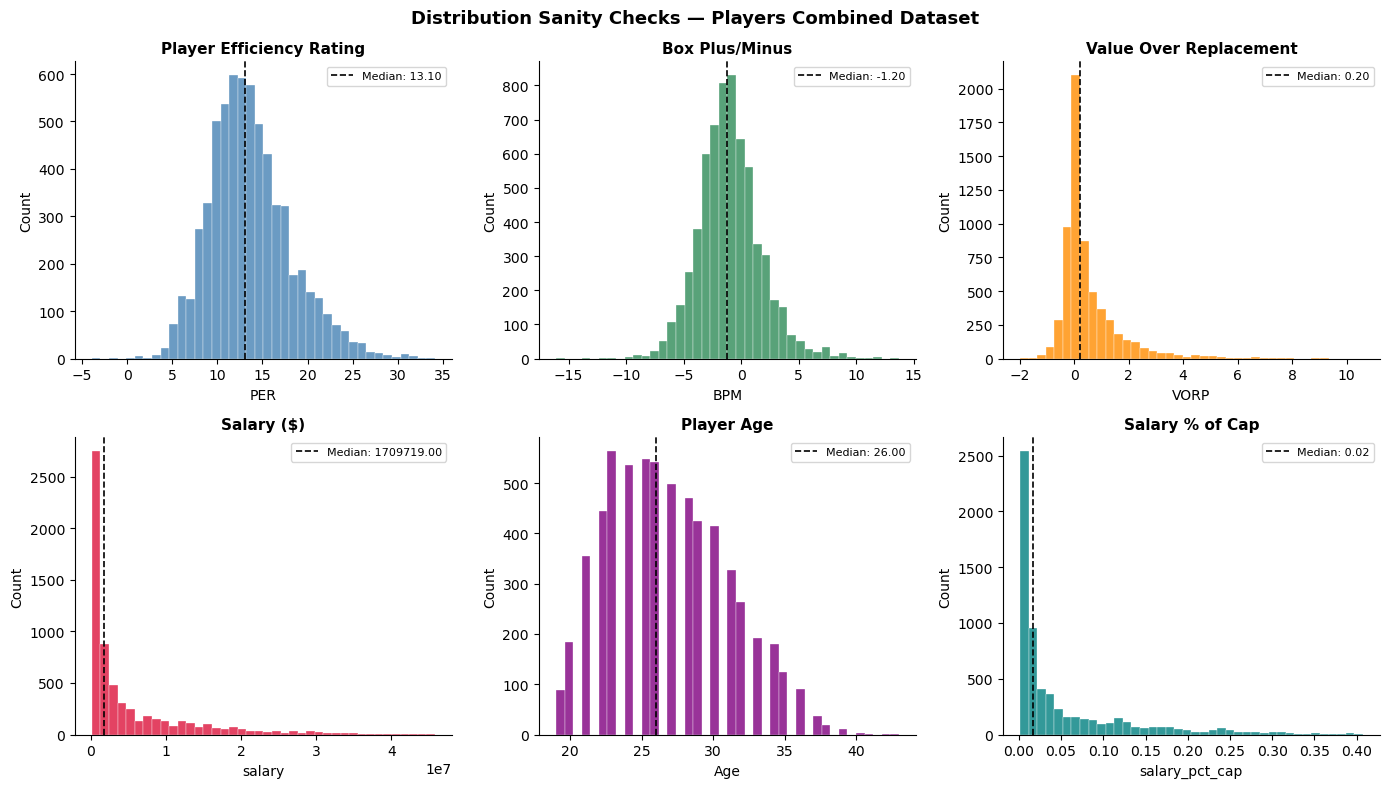

Saved → figures/data_distributions.png


In [97]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

checks = [
    ('PER',           'Player Efficiency Rating',  'steelblue'),
    ('BPM',           'Box Plus/Minus',             'seagreen'),
    ('VORP',          'Value Over Replacement',     'darkorange'),
    ('salary',        'Salary ($)',                 'crimson'),
    ('Age',           'Player Age',                 'purple'),
    ('salary_pct_cap','Salary % of Cap',            'teal'),
]

for ax, (col, label, color) in zip(axes.flatten(), checks):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.2, label=f'Median: {data.median():.2f}')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Distribution Sanity Checks — Players Combined Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/data_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → figures/data_distributions.png')

In [105]:
# Spot check: top 10 players by VORP in 2024 — should look reasonable
print('Top 10 players by VORP in 2024:')
top_vorp = df[df['season'] == 2024].nlargest(10, 'VORP')[['Player', 'Age', 'PER', 'BPM', 'VORP', 'salary']]
display(top_vorp.reset_index(drop=True))

print('\nTop 10 highest paid players in 2024:')
top_salary = df[df['season'] == 2024].nlargest(10, 'salary')[['Player', 'Age', 'PER', 'VORP', 'salary', 'salary_pct_cap']]
display(top_salary.reset_index(drop=True))

Top 10 players by VORP in 2024:


,Player,Age,PER,BPM,VORP,salary
0,Nikola Jokić,28.0,31.0,13.2,10.6,1000000.0
1,Luka Dončić,24.0,28.1,9.9,8.0,1000000.0
2,Giannis Antetokounmpo,29.0,29.9,9.0,7.2,1000000.0
3,Shai Gilgeous-Alexander,25.0,29.3,9.0,7.1,1000000.0
4,Domantas Sabonis,27.0,23.2,6.5,6.2,1000000.0
5,Jalen Brunson,27.0,23.4,5.8,5.4,1000000.0
6,LeBron James,39.0,23.7,6.5,5.4,1000000.0
7,Tyrese Haliburton,23.0,23.3,6.9,5.0,1000000.0
8,Anthony Davis,30.0,25.8,5.1,4.9,1000000.0
9,Jayson Tatum,25.0,22.3,5.1,4.7,1000000.0



Top 10 highest paid players in 2024:


,Player,Age,PER,VORP,salary,salary_pct_cap
0,A.J. Green,24.0,10.5,0.0,1000000.0,0.007352
1,A.J. Lawson,23.0,11.2,-0.2,1000000.0,0.007352
2,AJ Griffin,20.0,1.2,-0.3,1000000.0,0.007352
3,Aaron Gordon,28.0,16.8,1.9,1000000.0,0.007352
4,Aaron Holiday,27.0,11.5,0.2,1000000.0,0.007352
5,Aaron Nesmith,24.0,12.8,0.8,1000000.0,0.007352
6,Aaron Wiggins,25.0,15.6,0.8,1000000.0,0.007352
7,Admiral Schofield,26.0,6.0,-0.1,1000000.0,0.007352
8,Al Horford,37.0,15.0,2.5,1000000.0,0.007352
9,Alec Burks,32.0,12.9,-0.1,1000000.0,0.007352


---
## 9. Save Final Dataset

In [108]:
output_path = 'data/processed/players_combined.csv'
df.to_csv(output_path, index=False)

print(f'Saved → {output_path}')
print(f'Shape: {df.shape}')
print(f'\nFile size: {os.path.getsize(output_path) / 1024:.1f} KB')

print('\n--- READY FOR NEXT NOTEBOOKS ---')
print('02_feature_engineering.ipynb  → rolling averages, lag features')
print('03_regression.ipynb           → predict next-season PER, PTS, WS')
print('04_clustering.ipynb           → player archetype clustering')
print('05_trade_value.ipynb          → trade value score + leaderboard')

Saved → data/processed/players_combined.csv
Shape: (6326, 41)

File size: 1458.2 KB

--- READY FOR NEXT NOTEBOOKS ---
02_feature_engineering.ipynb  → rolling averages, lag features
03_regression.ipynb           → predict next-season PER, PTS, WS
04_clustering.ipynb           → player archetype clustering
05_trade_value.ipynb          → trade value score + leaderboard


---
## Summary

| Step | What we collected | Rows |
|---|---|---|
| Per-game stats | PTS, REB, AST, STL, BLK, shooting splits | ~5,000 player-seasons |
| Advanced stats | PER, BPM, VORP, TS%, WS, rate stats | ~5,000 player-seasons |
| Salary data | Contract value, cap % | ~4,500 player-seasons |
| **Merged output** | **All of the above in one file** | **~5,000 rows, 35+ columns** |

**Key decisions made here:**
- Players with < 20 games excluded
- Traded players: individual team stints kept, TOT rows dropped
- Missing salaries imputed with league minimum
- Salary normalized as % of that season's cap (accounts for cap growth 2015→2024)
- Composite score pre-computed for quick use downstream